<a href="https://colab.research.google.com/github/bashar730/heart-disease-ai/blob/data-eda/notebooks/01_Data_Understanding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Graduation Project:
# Intelligent Heart Disease Risk Prediction
# and Medical Decision Support System

# Team members:
# 1.
# 2.
# 3.

# Notebook purpose:
# Loading and understanding the heart disease dataset.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
!pip install -q ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# تحميل مجموعة Heart Disease الرسمية من UCI
heart_disease = fetch_ucirepo(id=45)

# الخصائص (Features)
X = heart_disease.data.features

# الهدف (Target)
y = heart_disease.data.targets

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [ ]:

display(X.head())

display(y.head())

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


,num
0,0
1,2
2,1
3,0
4,0


In [ ]:

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (303, 13)
Target shape: (303, 1)


In [ ]:

X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
dtypes: float64(3), int64(10)
memory usage: 30.9 KB


In [ ]:
# عرض أسماء الأعمدة
print("Column names:")
print(X.columns.tolist())

Column names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [ ]:
# حساب القيم المفقودة في كل عمود
missing_values = X.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
dtype: int64


In [ ]:
# عرض القيم المختلفة في العمود الهدف
print("Unique target values:")
print(y["num"].unique())

# حساب عدد الحالات في كل فئة
print("\nTarget value counts:")
print(y["num"].value_counts().sort_index())

Unique target values:
[0 2 1 3 4]

Target value counts:
num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64


In [ ]:
# الإحصاءات الوصفية للبيانات
X.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000


In [ ]:
# فحص عدد الصفوف المكررة
duplicate_rows = X.duplicated().sum()

print("Number of duplicate rows:", duplicate_rows)

Number of duplicate rows: 0


In [ ]:
# الأعمدة الرقمية (Numerical Features)
numerical_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

# الأعمدة الفئوية (Categorical Features)
categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

Categorical Features:
['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']


In [ ]:
import seaborn as sns

print("Seaborn imported successfully.")

Seaborn imported successfully.


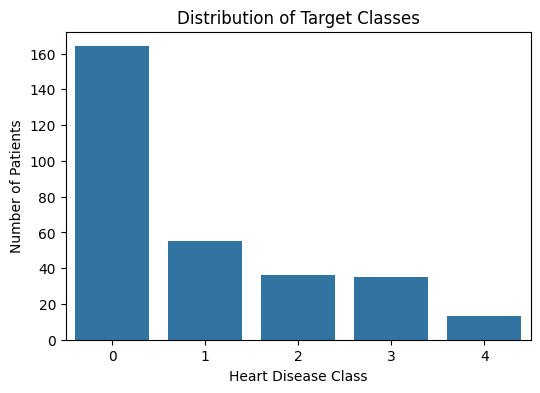

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x=y["num"])

plt.title("Distribution of Target Classes")
plt.xlabel("Heart Disease Class")
plt.ylabel("Number of Patients")

plt.show()

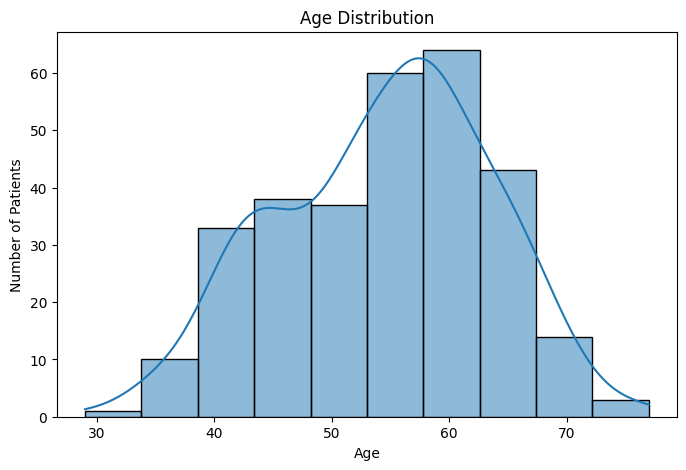

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(X["age"], bins=10, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()

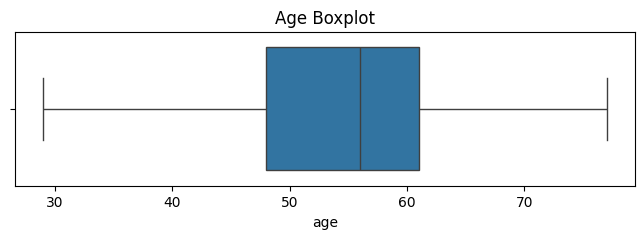

In [ ]:
plt.figure(figsize=(8,2))

sns.boxplot(x=X["age"])

plt.title("Age Boxplot")

plt.show()

In [ ]:
# إنشاء نسخة من العمود الهدف
y_binary = y.copy()

# تحويل جميع القيم الأكبر من صفر إلى 1
y_binary["num"] = y_binary["num"].apply(lambda x: 0 if x == 0 else 1)

print("Target converted successfully.")

Target converted successfully.


In [ ]:
print(y_binary["num"].value_counts())

num
0    164
1    139
Name: count, dtype: int64


In [ ]:
# دمج الخصائص مع الهدف الجديد
df = X.copy()

df["target"] = y_binary["num"]

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


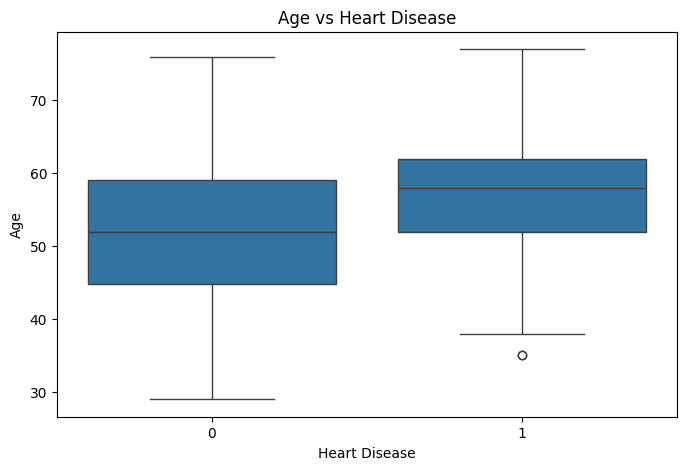

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x="target", y="age", data=df)

plt.title("Age vs Heart Disease")
plt.xlabel("Heart Disease")
plt.ylabel("Age")

plt.show()

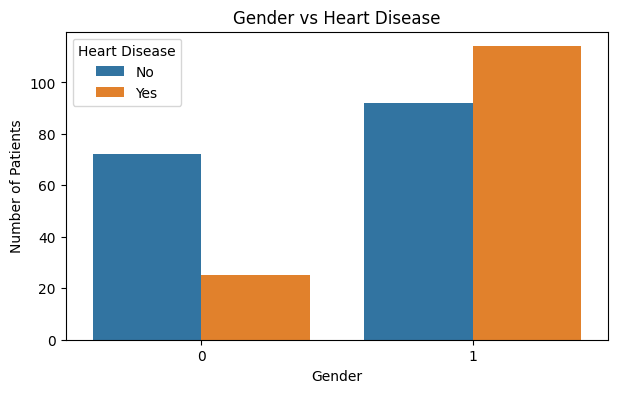

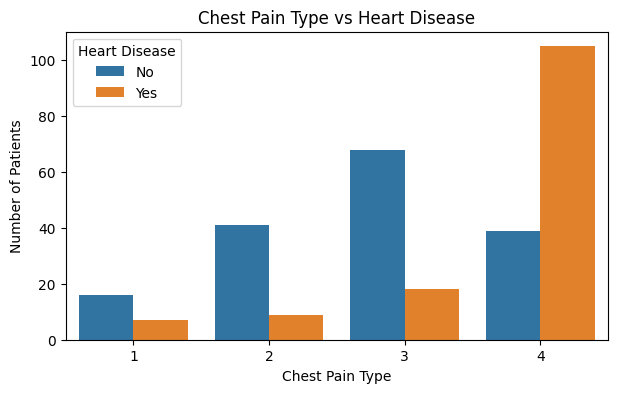

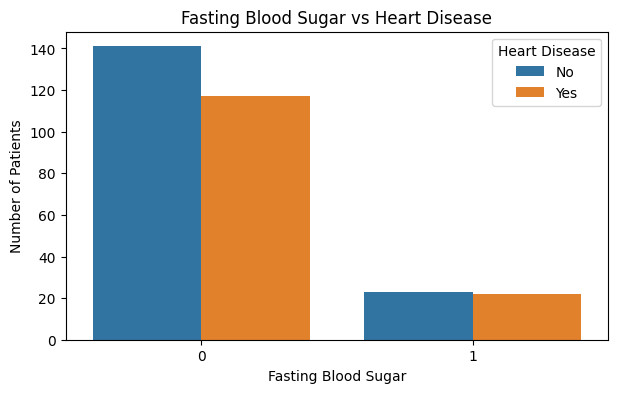

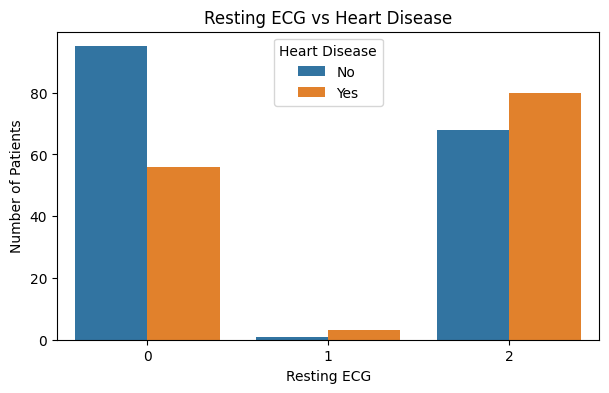

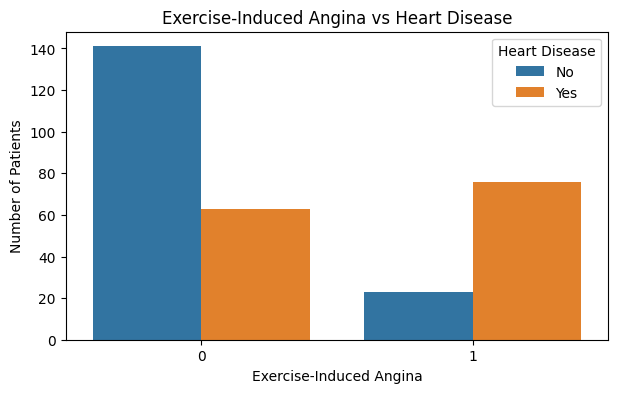

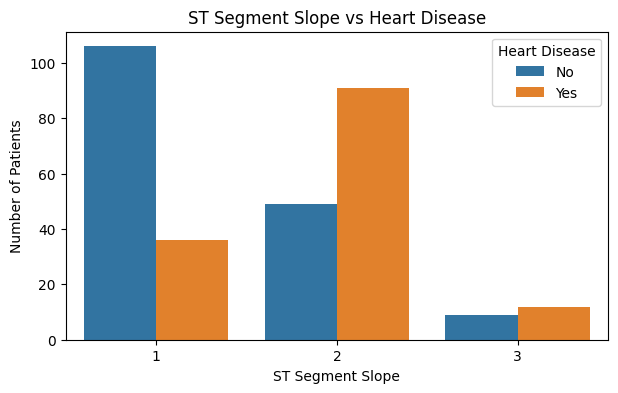

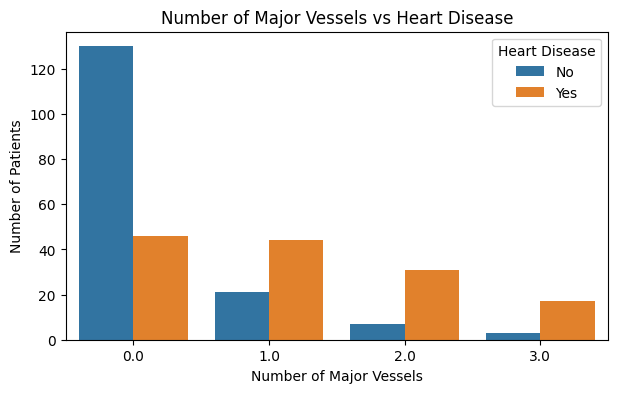

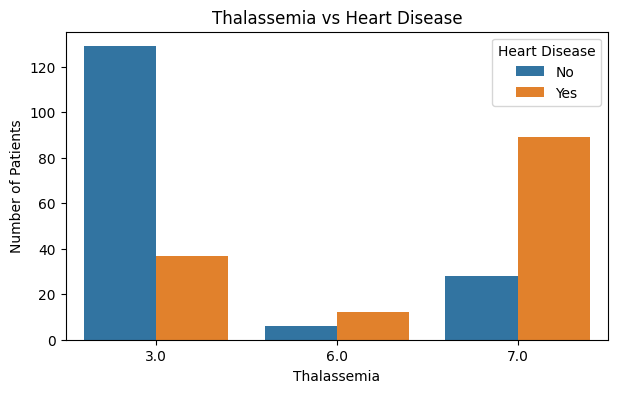

In [ ]:
# ==========================================
# Categorical Features Analysis
# ==========================================

# أسماء الأعمدة الفئوية
categorical_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

# أسماء احترافية ستظهر في عناوين الرسوم
feature_names = {
    "sex": "Gender",
    "cp": "Chest Pain Type",
    "fbs": "Fasting Blood Sugar",
    "restecg": "Resting ECG",
    "exang": "Exercise-Induced Angina",
    "slope": "ST Segment Slope",
    "ca": "Number of Major Vessels",
    "thal": "Thalassemia"
}

# رسم جميع الأعمدة الفئوية
for feature in categorical_features:

    plt.figure(figsize=(7,4))

    sns.countplot(x=feature, hue="target", data=df)

    plt.title(f"{feature_names[feature]} vs Heart Disease")

    plt.xlabel(feature_names[feature])
    plt.ylabel("Number of Patients")

    plt.legend(title="Heart Disease", labels=["No", "Yes"])

    plt.show()

## Observations from Categorical Features Analysis

### **Gender** (Sex)
- The number of male patients is higher than the number of female patients.
- Male patients show a higher number of heart disease cases compared to females.
- This observation should be interpreted considering that the
### **Chest Pain Type** (CP)
- Chest pain type 4 (Asymptomatic) has the highest number of heart disease cases.
- This suggests that the absence of typical chest pain does not necessarily indicate the absence of heart disease.

### **Fasting Blood Sugar** (FBS)
- Most patients have normal fasting blood sugar levels (FBS = 0).
- No clear difference is observed between patients with and without heart disease based on fasting blood sugar alone.

### **Resting** ECG
- Most patients belong to ECG categories 0 and 2.
- Patients with Resting ECG = 2 show a higher number of heart disease cases compared to category 0.
- Category 1 contains very few samples, making it difficult to draw reliable conclusions.

### **Exercise-Induced Angina**
- Patients with exercise-induced angina (Exang = 1) show a noticeably higher number of heart disease cases.
- Patients without exercise-induced angina (Exang = 0) are more likely to be free from heart disease.
- This feature appears to have a strong relationship with heart disease in the dataset.

### **ST Segment Slope**
- Most patients with ST Segment Slope = 1 do not have heart disease.
- Patients with ST Segment Slope = 2 show a higher number of heart disease cases.
- Category 3 contains relatively few samples, making its interpretation less reliable.

### **Number of Major Vessels** (CA)
- Most patients with CA = 0 do not have heart disease.
- Higher CA values are associated with a greater number of heart disease cases.
- This feature appears to have a strong relationship with heart disease in the dataset.

### **Thalassemia**
- Most patients with Thal = 3 do not have heart disease.
- Patients with Thal = 7 show a considerably higher number of heart disease cases.
- Category 6 contains relatively few samples, making its interpretation less reliable.